In [36]:


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
import tensorflow.random as tf_r
import keras_tuner
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras import Input
from scipy.optimize import curve_fit

import BuildModel as BM
import time
import os

plt.rcParams['font.size'] = 14

np.random.seed(12345)
tf_r.set_seed(12345)

In [37]:
np.random.seed(12345)

jump = lambda drift1, drift2, std1, std2: [int(np.random.normal(drift1,std1)), int(np.random.normal(drift2, std2))]

def pattern(i,z1,z2,a1,a2):
    return [int(a1*np.sin((np.pi*i)/z1)), int(a2*np.sin((np.pi*i)/z2))]

In [44]:
twoSNRs = [0.1, 0.3, 1, 3, 10,30]

In [38]:
SNRs = [0.05, 0.15, 0.5, 1.5, 5, 15] #30,100

# training set size and time series
N=10000
L=60
n_class = 3
# noise bias 
bias = 5 

#duration of the pattern
d = 11
# since i want to test the effectiveness of SNR as a measure classifiability 
# i start by seeing if different training sets (different amplitude and time)
# but with same SNR give more or less the same result: similar accuracy after
# a fixed number of epochs
pattern_params = []
sigma = 20


for SNR in SNRs:
    A_1 = (2*(np.pi + 4)*d*SNR / np.pi**3)**0.5 * sigma
    A_2 = (2*(np.pi + 4)*d*SNR / np.pi**3)**0.5 * sigma
    pattern_params.append( (A_1, sigma, bias, A_2, sigma, bias) ) 

    
    
# run only to generate data
y = np.zeros(N) # 1D (same label)
x = np.zeros((N,L))
acc = []

BATCH_SIZE = 200
EPOCHS = 250

models = []
datasets = []
labels = []



for params in pattern_params:
    
    y = np.zeros(N) # 1D (same label)
    x = np.zeros((N,L,2))
    Z1 = Z2 = d
   
    A1, DX1, bias1, A2, DX2, bias2 = params
    for i in range(N):
            if i>0: 
                jump0, jump1 = jump(bias1, bias2, DX1, DX2)
                x[i][0][0] = x[i-1][-1][0] + jump0 
                x[i][0][1] = x[i-1][-1][1] + jump1
            
            for j in range(1,L):
                jump0, jump1 = jump(bias1, bias2, DX1, DX2)
                x[i][j][0] = x[i][j-1][0] + jump0
                x[i][j][1] = x[i][j-1][1] + jump1
                
            y[i] = i%3 # assign class labels (0,1,2,3,4,5,6)
                   
            if y[i]>0:
                # 0 -> 0 0
                if y[i]<3:
                    j01, j02 = np.random.randint(0,L-1-d, 2) 
                    sign = 3-2*y[i] 
                    
                    
                    for j in range(d): 
                       p_val1, p_val2 = pattern(j, d, d, A1, A2)
        
                       x[i][j01 + j][0] += sign * p_val1 # Canale 0
                       x[i][j02 + j][1] += sign * p_val2 # Canale 1
    datasets.append(x)
    labels.append(y)
    #Show_data2D(x)
    model = BM.build_model(L, n_class=n_class)
    start = time.time()
    categ = y
    y = np.zeros((N,n_class))
    for i in range(N):
        y[i][int(categ[i])] = 1. # y contains one-hot encoding


    perc_train=0.8
    N_train = int(perc_train*N)
    x_train = x[:N_train]
    
    y_train = y[:N_train]
    x_val = x[N_train:]
    y_val = y[N_train:]
    N_val = len(x_val)
    
     
    #remove average value of each sample from its values
    xm_train = x_train.mean(axis=1)
    std_train = x_train.std(axis=1)
    xm_val = x_val.mean(axis=1)
    std_val = x_val.std(axis=1)
    # rescale with variance on the training set
    for i in range(N_train):
         x_train[i] = (x_train[i]-xm_train[i])/ std_train.mean(axis=0)
    for i in range(N_val):
        x_val[i] = (x_val[i]-xm_val[i])/ std_val.mean(axis=0)

    x_train = x_train.reshape(x_train.shape[0], L, 2)
    x_val =  x_val.reshape(x_val.shape[0], L, 2)
    
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True
    )
    
    fit = model.fit(x_train, y_train,
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=(x_val, y_val),
                    verbose=False,
                    shuffle=True,
                    callbacks=[early_stop])
    
    # Prendi il MASSIMO, non l'ultimo
    acc.append(max(fit.history['val_accuracy']))
    models.append(model)
    stop = time.time()
    delta = stop - start
    print(f"Done for {params[0]}, {params[1]}, {max(fit.history['val_accuracy'])},{delta}")

/home/lenovo/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Done for 10.066976775827971, 20, 0.3375000059604645,10.00903844833374
Done for 17.43651525434997, 20, 0.34200000762939453,8.730497598648071
Done for 31.834575763634692, 20, 0.375,26.996381044387817
Done for 55.13910266001608, 20, 0.5055000185966492,35.7875816822052
Done for 100.6697677582797, 20, 0.8454999923706055,33.29188513755798
Done for 174.3651525434997, 20, 0.9965000152587891,40.970515966415405


In [39]:
ACC = []

for m in models:
    accuracies = []

    for i in range(len(SNRs)):

        x_test = datasets[i]

        y_test = np.array(labels[i]).astype(np.int64)  

        y_test_oh = np.eye(n_class)[y_test]

        loss, acc = m.evaluate(x_test, y_test_oh, verbose=0)
        accuracies.append(acc)

    ACC.append(accuracies)

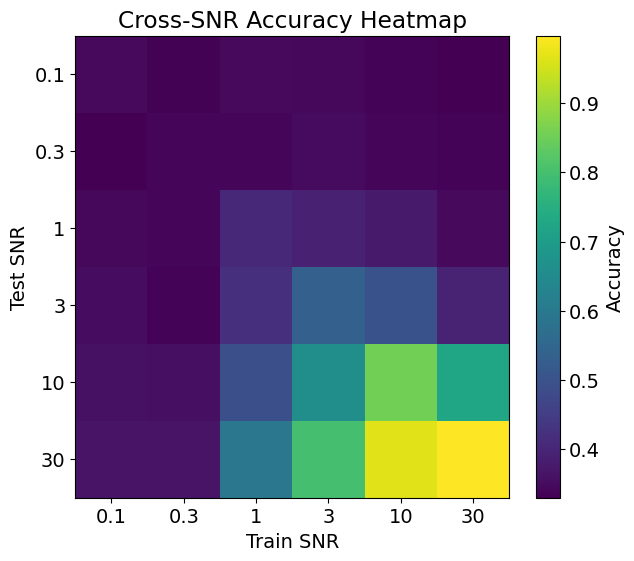

In [46]:
import numpy as np
import matplotlib.pyplot as plt

ACC = np.array(ACC).T

plt.figure(figsize=(7, 6))

im = plt.imshow(ACC, interpolation='nearest', aspect='auto')

plt.colorbar(im, label="Accuracy")

plt.xticks(range(len(SNRs)), twoSNRs)
plt.yticks(range(len(SNRs)), twoSNRs)

plt.ylabel("Test SNR")
plt.xlabel("Train SNR")
plt.title("Cross-SNR Accuracy Heatmap")

plt.show()

In [47]:
np.save('accuracies_test',ACC)

In [48]:
col_means = []

for i in range(len(SNRs)):
    values = np.delete(ACC[:, i], i)  
    col_means.append(values.mean())

col_means = np.array(col_means)

print(col_means)

[0.35052    0.34664    0.43976    0.50918001 0.50464    0.42644   ]


In [50]:
max_idx = np.argmax(col_means)
max_val = col_means[max_idx]

print("Max col mean:", max_val)
print("corresponding SNR:", twoSNRs[max_idx])

Max col mean: 0.5091800093650818
corresponding SNR: 3


In [51]:
SNRs = [1, 2, 3, 4, 5] 

# training set size and time series
N=10000
L=60
n_class = 3
# noise bias 
bias = 5 

#duration of the pattern
d = 11
# since i want to test the effectiveness of SNR as a measure classifiability 
# i start by seeing if different training sets (different amplitude and time)
# but with same SNR give more or less the same result: similar accuracy after
# a fixed number of epochs
pattern_params = []
sigma = 20


for SNR in SNRs:
    A_1 = (2*(np.pi + 4)*d*SNR / np.pi**3)**0.5 * sigma
    A_2 = (2*(np.pi + 4)*d*SNR / np.pi**3)**0.5 * sigma
    pattern_params.append( (A_1, sigma, bias, A_2, sigma, bias) ) 

    
    
# run only to generate data
y = np.zeros(N) # 1D (same label)
x = np.zeros((N,L))
acc = []

BATCH_SIZE = 200
EPOCHS = 250

models = []
datasets = []
labels = []



for params in pattern_params:
    
    y = np.zeros(N) # 1D (same label)
    x = np.zeros((N,L,2))
    Z1 = Z2 = d
   
    A1, DX1, bias1, A2, DX2, bias2 = params
    for i in range(N):
            if i>0: 
                jump0, jump1 = jump(bias1, bias2, DX1, DX2)
                x[i][0][0] = x[i-1][-1][0] + jump0 
                x[i][0][1] = x[i-1][-1][1] + jump1
            
            for j in range(1,L):
                jump0, jump1 = jump(bias1, bias2, DX1, DX2)
                x[i][j][0] = x[i][j-1][0] + jump0
                x[i][j][1] = x[i][j-1][1] + jump1
                
            y[i] = i%3 # assign class labels (0,1,2,3,4,5,6)
                   
            if y[i]>0:
                # 0 -> 0 0
                if y[i]<3:
                    j01, j02 = np.random.randint(0,L-1-d, 2) 
                    sign = 3-2*y[i] 
                    
                    
                    for j in range(d): 
                       p_val1, p_val2 = pattern(j, d, d, A1, A2)
        
                       x[i][j01 + j][0] += sign * p_val1 # Canale 0
                       x[i][j02 + j][1] += sign * p_val2 # Canale 1
    datasets.append(x)
    labels.append(y)
    #Show_data2D(x)
    model = BM.build_model(L, n_class=n_class)
    start = time.time()
    categ = y
    y = np.zeros((N,n_class))
    for i in range(N):
        y[i][int(categ[i])] = 1. # y contains one-hot encoding


    perc_train=0.8
    N_train = int(perc_train*N)
    x_train = x[:N_train]
    
    y_train = y[:N_train]
    x_val = x[N_train:]
    y_val = y[N_train:]
    N_val = len(x_val)
    
     
    #remove average value of each sample from its values
    xm_train = x_train.mean(axis=1)
    std_train = x_train.std(axis=1)
    xm_val = x_val.mean(axis=1)
    std_val = x_val.std(axis=1)
    # rescale with variance on the training set
    for i in range(N_train):
         x_train[i] = (x_train[i]-xm_train[i])/ std_train.mean(axis=0)
    for i in range(N_val):
        x_val[i] = (x_val[i]-xm_val[i])/ std_val.mean(axis=0)

    x_train = x_train.reshape(x_train.shape[0], L, 2)
    x_val =  x_val.reshape(x_val.shape[0], L, 2)
    
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True
    )
    
    fit = model.fit(x_train, y_train,
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=(x_val, y_val),
                    verbose=False,
                    shuffle=True,
                    callbacks=[early_stop])
    
    # Prendi il MASSIMO, non l'ultimo
    acc.append(max(fit.history['val_accuracy']))
    models.append(model)
    stop = time.time()
    delta = stop - start
    print(f"Done for {params[0]}, {params[1]}, {max(fit.history['val_accuracy'])},{delta}")

/home/lenovo/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Done for 45.02088879732601, 20, 0.4269999861717224,14.25428819656372
Done for 63.669151527269385, 20, 0.5414999723434448,30.612977266311646
Done for 77.97846679887714, 20, 0.6995000243186951,32.15239405632019
Done for 90.04177759465202, 20, 0.7310000061988831,16.80851173400879
Done for 100.6697677582797, 20, 0.8510000109672546,36.25864005088806


In [52]:
twoSNRs = [2, 4, 6, 8, 10]

In [53]:
ACC = []

for m in models:
    accuracies = []

    for i in range(len(SNRs)):

        x_test = datasets[i]

        y_test = np.array(labels[i]).astype(np.int64)  

        y_test_oh = np.eye(n_class)[y_test]

        loss, acc = m.evaluate(x_test, y_test_oh, verbose=0)
        accuracies.append(acc)

    ACC.append(accuracies)

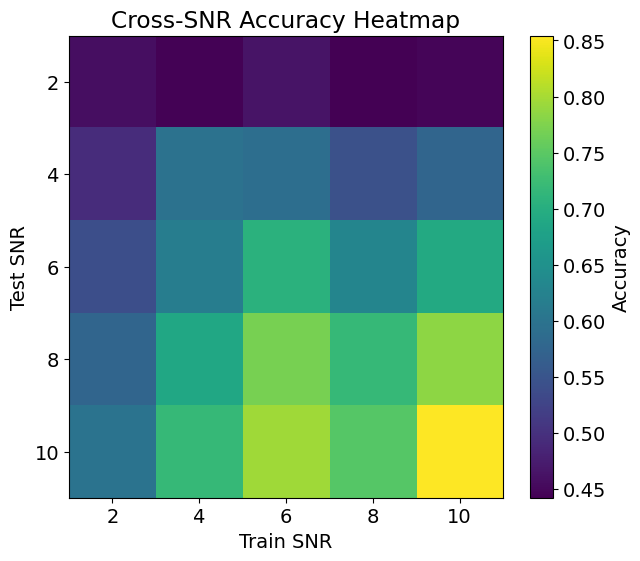

In [55]:
import numpy as np
import matplotlib.pyplot as plt

ACC = np.array(ACC).T

plt.figure(figsize=(7, 6))

im = plt.imshow(ACC, interpolation='nearest', aspect='auto')

plt.colorbar(im, label="Accuracy")

plt.xticks(range(len(SNRs)), twoSNRs)
plt.yticks(range(len(SNRs)), twoSNRs)

plt.ylabel("Test SNR")
plt.xlabel("Train SNR")
plt.title("Cross-SNR Accuracy Heatmap")

plt.show()

In [56]:
col_means = []

for i in range(len(SNRs)):
    values = np.delete(ACC[:, i], i)  
    col_means.append(values.mean())

col_means = np.array(col_means)

print(col_means)

[0.55289999 0.61705    0.65510001 0.59079999 0.62547501]


In [57]:
max_idx = np.argmax(col_means)
max_val = col_means[max_idx]

print("Max col mean:", max_val)
print("corresponding SNR:", twoSNRs[max_idx])

Max col mean: 0.6551000103354454
corresponding SNR: 6
